# Drone Flight Data Analysis Project Using Python

This project analyzes various types of drone performance metrics such as battery capacity,
motor current, drone weight, flight time and maximum distance. The goal is to understand which factors influence drone efficiency and flight performance.

Objective :
    The objective of this analysis is to explore relationships between key drone specifications and performance metrics to identify factors that influence filght distance,efficiency and overall drone capability.

# Import Libraries

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import os
os.makedirs('Picture',exist_ok='True')
sns.set_style('darkgrid')

In [2]:
df_raw = pd.read_csv(r"C:\Users\User\Downloads\drone_flight_dataset_mixed_types.csv")
df_raw
df_raw.columns
df_raw.shape
df_raw.describe()

,id,motor_count,motor_current,total_current,battery_capacity,usable_battery,estimated_time,total_weight,cruise_speed,max_distance,target_distance
count,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.00000
mean,50.500000,6.26000,13.947500,41.292400,14719.880000,11910.266200,21.063600,3.920000,15.22260,7.944400,6.26140
std,29.011492,1.64912,3.364918,16.089949,4195.998491,3522.761367,7.929995,1.598499,4.06352,2.378369,2.37825
min,1.000000,4.00000,8.040000,14.070000,8005.000000,6076.080000,8.310000,1.240000,8.06000,4.040000,2.03000
25%,25.750000,4.00000,11.295000,29.727500,11089.000000,8681.530000,14.147500,2.622500,11.99250,6.220000,4.33250
50%,50.500000,6.00000,14.130000,38.790000,14674.000000,11880.565000,19.975000,3.905000,15.06000,7.735000,6.15000
75%,75.250000,8.00000,16.832500,52.430000,18361.250000,14811.272500,28.012500,5.332500,18.73750,9.942500,8.60750
max,100.000000,8.00000,19.900000,80.360000,21876.000000,19424.670000,34.540000,6.470000,21.85000,11.990000,9.96000


# Check errors

In [3]:
df_raw.isnull().sum()
df_raw.drop_duplicates()
df_clean = df_raw.drop_duplicates()
df_clean

,id,drone_type,motor_count,motor_current,total_current,battery_capacity,usable_battery,estimated_time,total_weight,cruise_speed,max_distance,target_distance,can_reach
0,1,quad,4,16.66,35.87,14674,13203.54,8.88,2.04,13.92,6.67,9.27,NO
1,2,hexa,6,11.45,34.03,16271,13198.80,8.96,4.39,16.29,6.45,8.91,NO
2,3,octa,8,18.32,58.76,21617,19424.67,25.08,6.25,10.20,4.65,5.91,NO
3,4,octa,8,8.48,34.56,21531,19329.94,19.04,5.60,14.33,7.53,4.90,YES
4,5,hexa,6,12.09,31.95,9939,8686.73,28.18,2.98,8.06,9.93,2.35,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,hexa,6,14.46,35.71,11943,9438.47,10.04,6.47,15.42,9.62,5.68,YES
96,97,octa,8,12.38,46.32,8847,6405.14,29.57,2.66,20.82,9.02,8.94,YES
97,98,octa,8,18.55,60.29,17131,15026.80,10.30,3.98,12.12,7.31,8.84,NO
98,99,quad,4,12.57,23.86,17083,12865.25,34.11,1.74,8.95,10.91,9.34,YES


# Double Check

In [4]:
df_clean.columns
df_clean.shape
df_clean.describe()

,id,motor_count,motor_current,total_current,battery_capacity,usable_battery,estimated_time,total_weight,cruise_speed,max_distance,target_distance
count,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.00000
mean,50.500000,6.26000,13.947500,41.292400,14719.880000,11910.266200,21.063600,3.920000,15.22260,7.944400,6.26140
std,29.011492,1.64912,3.364918,16.089949,4195.998491,3522.761367,7.929995,1.598499,4.06352,2.378369,2.37825
min,1.000000,4.00000,8.040000,14.070000,8005.000000,6076.080000,8.310000,1.240000,8.06000,4.040000,2.03000
25%,25.750000,4.00000,11.295000,29.727500,11089.000000,8681.530000,14.147500,2.622500,11.99250,6.220000,4.33250
50%,50.500000,6.00000,14.130000,38.790000,14674.000000,11880.565000,19.975000,3.905000,15.06000,7.735000,6.15000
75%,75.250000,8.00000,16.832500,52.430000,18361.250000,14811.272500,28.012500,5.332500,18.73750,9.942500,8.60750
max,100.000000,8.00000,19.900000,80.360000,21876.000000,19424.670000,34.540000,6.470000,21.85000,11.990000,9.96000


# Add engineering features

In [5]:
def add_battery_efficiency(df):
    df = df.copy()
    df['battery_efficiency_per_1000mAh'] = df['max_distance'] / df['usable_battery'] * 1000
    return df 
def add_power_efficiency(df):
    df = df.copy()
    df['power_efficiency'] = df['max_distance'] /df['total_current']
    return df
def add_weight_efficiency(df):
    df = df.copy()
    df['weight_efficiency'] =df['max_distance']/df['total_weight']
    return df 
def add_speed(df):
    df = df.copy()
    df['avg_speed'] = df['max_distance'] / df['estimated_time']
    return df
def add_battery_drain_rate(df):
    df = df.copy()
    df['battery_drain_rate'] = df['usable_battery'] / df['estimated_time'] 
    return df
def add_performance_score(df):
    df = df.copy()
    df['performance_score'] = (df['battery_efficiency_per_1000mAh']+df['power_efficiency']+df['weight_efficiency'])/3
    return df

def add_performance_category(df):
    df = df.copy()
    df['performance_category'] = pd.qcut(df['performance_score'],
                                         q=3,
                                         labels=['Low',"Medium","High"])
    return df

In [6]:
df_clean = add_battery_efficiency(df_clean)
df_clean = add_weight_efficiency(df_clean)
df_clean = add_power_efficiency(df_clean)
df_clean

,id,drone_type,motor_count,motor_current,total_current,battery_capacity,usable_battery,estimated_time,total_weight,cruise_speed,max_distance,target_distance,can_reach,battery_efficiency_per_1000mAh,weight_efficiency,power_efficiency
0,1,quad,4,16.66,35.87,14674,13203.54,8.88,2.04,13.92,6.67,9.27,NO,0.505168,3.269608,0.185949
1,2,hexa,6,11.45,34.03,16271,13198.80,8.96,4.39,16.29,6.45,8.91,NO,0.488681,1.469248,0.189539
2,3,octa,8,18.32,58.76,21617,19424.67,25.08,6.25,10.20,4.65,5.91,NO,0.239386,0.744000,0.079135
3,4,octa,8,8.48,34.56,21531,19329.94,19.04,5.60,14.33,7.53,4.90,YES,0.389551,1.344643,0.217882
4,5,hexa,6,12.09,31.95,9939,8686.73,28.18,2.98,8.06,9.93,2.35,YES,1.143123,3.332215,0.310798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,hexa,6,14.46,35.71,11943,9438.47,10.04,6.47,15.42,9.62,5.68,YES,1.019233,1.486862,0.269392
96,97,octa,8,12.38,46.32,8847,6405.14,29.57,2.66,20.82,9.02,8.94,YES,1.408244,3.390977,0.194732
97,98,octa,8,18.55,60.29,17131,15026.80,10.30,3.98,12.12,7.31,8.84,NO,0.486464,1.836683,0.121247
98,99,quad,4,12.57,23.86,17083,12865.25,34.11,1.74,8.95,10.91,9.34,YES,0.848021,6.270115,0.457251


In [7]:
df_clean = add_battery_drain_rate(df_clean)
df_clean = add_speed(df_clean)
df_clean

,id,drone_type,motor_count,motor_current,total_current,battery_capacity,usable_battery,estimated_time,total_weight,cruise_speed,max_distance,target_distance,can_reach,battery_efficiency_per_1000mAh,weight_efficiency,power_efficiency,battery_drain_rate,avg_speed
0,1,quad,4,16.66,35.87,14674,13203.54,8.88,2.04,13.92,6.67,9.27,NO,0.505168,3.269608,0.185949,1486.885135,0.751126
1,2,hexa,6,11.45,34.03,16271,13198.80,8.96,4.39,16.29,6.45,8.91,NO,0.488681,1.469248,0.189539,1473.080357,0.719866
2,3,octa,8,18.32,58.76,21617,19424.67,25.08,6.25,10.20,4.65,5.91,NO,0.239386,0.744000,0.079135,774.508373,0.185407
3,4,octa,8,8.48,34.56,21531,19329.94,19.04,5.60,14.33,7.53,4.90,YES,0.389551,1.344643,0.217882,1015.227941,0.395483
4,5,hexa,6,12.09,31.95,9939,8686.73,28.18,2.98,8.06,9.93,2.35,YES,1.143123,3.332215,0.310798,308.258694,0.352378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,hexa,6,14.46,35.71,11943,9438.47,10.04,6.47,15.42,9.62,5.68,YES,1.019233,1.486862,0.269392,940.086653,0.958167
96,97,octa,8,12.38,46.32,8847,6405.14,29.57,2.66,20.82,9.02,8.94,YES,1.408244,3.390977,0.194732,216.609401,0.305039
97,98,octa,8,18.55,60.29,17131,15026.80,10.30,3.98,12.12,7.31,8.84,NO,0.486464,1.836683,0.121247,1458.912621,0.709709
98,99,quad,4,12.57,23.86,17083,12865.25,34.11,1.74,8.95,10.91,9.34,YES,0.848021,6.270115,0.457251,377.169452,0.319848


In [8]:
df_clean = add_performance_score(df_clean)
df_clean = add_performance_category(df_clean)
df_clean

,id,drone_type,motor_count,motor_current,total_current,battery_capacity,usable_battery,estimated_time,total_weight,cruise_speed,max_distance,target_distance,can_reach,battery_efficiency_per_1000mAh,weight_efficiency,power_efficiency,battery_drain_rate,avg_speed,performance_score,performance_category
0,1,quad,4,16.66,35.87,14674,13203.54,8.88,2.04,13.92,6.67,9.27,NO,0.505168,3.269608,0.185949,1486.885135,0.751126,1.320242,High
1,2,hexa,6,11.45,34.03,16271,13198.80,8.96,4.39,16.29,6.45,8.91,NO,0.488681,1.469248,0.189539,1473.080357,0.719866,0.715823,Low
2,3,octa,8,18.32,58.76,21617,19424.67,25.08,6.25,10.20,4.65,5.91,NO,0.239386,0.744000,0.079135,774.508373,0.185407,0.354174,Low
3,4,octa,8,8.48,34.56,21531,19329.94,19.04,5.60,14.33,7.53,4.90,YES,0.389551,1.344643,0.217882,1015.227941,0.395483,0.650692,Low
4,5,hexa,6,12.09,31.95,9939,8686.73,28.18,2.98,8.06,9.93,2.35,YES,1.143123,3.332215,0.310798,308.258694,0.352378,1.595379,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,hexa,6,14.46,35.71,11943,9438.47,10.04,6.47,15.42,9.62,5.68,YES,1.019233,1.486862,0.269392,940.086653,0.958167,0.925163,Medium
96,97,octa,8,12.38,46.32,8847,6405.14,29.57,2.66,20.82,9.02,8.94,YES,1.408244,3.390977,0.194732,216.609401,0.305039,1.664651,High
97,98,octa,8,18.55,60.29,17131,15026.80,10.30,3.98,12.12,7.31,8.84,NO,0.486464,1.836683,0.121247,1458.912621,0.709709,0.814798,Medium
98,99,quad,4,12.57,23.86,17083,12865.25,34.11,1.74,8.95,10.91,9.34,YES,0.848021,6.270115,0.457251,377.169452,0.319848,2.525129,High


In [9]:
df_clean.to_csv('drone_analysis.csv', index= False)

# Visualization Functions

Define reusable plotting functions to maintain consistent visualization style throughout the analysis.

# Function for the histogram plot 

In [10]:
def plot_hist(data,column,bins=20,kde=True,hue=None,title=None,figsize=(8,5),ax=None):
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    sns.histplot(data=data, x=column,bins=bins,kde=kde,hue=hue,ax=ax)
    mean_value = data[column].mean()
    ax.axvline(mean_value,color='red',linestyle='--',
               label =f"Mean:{mean_value:.2f}")
    ax.set_title(title,weight='bold',fontsize=16)
    ax.set_xlabel(column,weight='bold')
    ax.set_ylabel('Count',weight='bold')
    
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    

# Function for Bar Plot 

In [11]:
def plot_bar(data,x,y=None,hue=None,title=None,figsize=(8,5),ax=None):
    
    plt.figure(figsize = figsize)
    if y is None:
        sns.countplot(data=data,x=x,hue=hue)
    else :
        sns.barplot(data = data,x=x,y=y,hue=hue)
    plt.title(title,weight='bold',fontsize=16)
    
    plt.xlabel(x,weight='bold')
    plt.gca().bar_label(plt.gca().containers[0])
    if y:
        plt.ylabel(y,weight='bold')
    else:
        plt.ylabel('Count',weight='bold')
        
    filename = title.replace(" ","_").lower()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"Picture/{filename}.jpg",dpi=300)
    plt.show()

# Function for the Scatter Plot

In [25]:
def plot_scatter(data,x,y=None,hue=None,title=None,figsize=(8,5),alpha=0.7):
    plt.figure(figsize = figsize)
    if y is None:
        sns.countplot(data=data,x=x,hue=hue)
    else :
        sns.scatterplot(data = data,x=x,y=y,hue=hue,alpha = alpha)
    plt.title(title,weight='bold',fontsize=16)
    plt.xlabel(x,weight='bold')
    if y:
        plt.ylabel(y,weight='bold')
    else:
        plt.ylabel('Count',weight='bold')
    filename = title.replace(" ","_").lower()
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"Picture/{filename}.jpg",dpi=300)
    plt.show()

# Relationship Analysis

In [13]:
def plot_box(data,x,y,hue=None,title=None,figsize=(8,5)):
    
    plt.figure(figsize=figsize)
    sns.boxplot(data=data, x=x,y=y,hue=hue,showmeans=True)
    """
    mean_value = data[y].mean()
    plt.axhline(mean_value,color='red',linestyle='--',
               label =f"Mean:{mean_value:.2f}")
    """
    plt.title(title,weight='bold',fontsize=16)
    plt.xlabel(x,weight='bold')
    plt.ylabel(y,weight='bold')
    filename = title.replace(" ","_").lower()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"Picture/{filename}.jpg",dpi=300)
    plt.show()

# Dataset Overview 

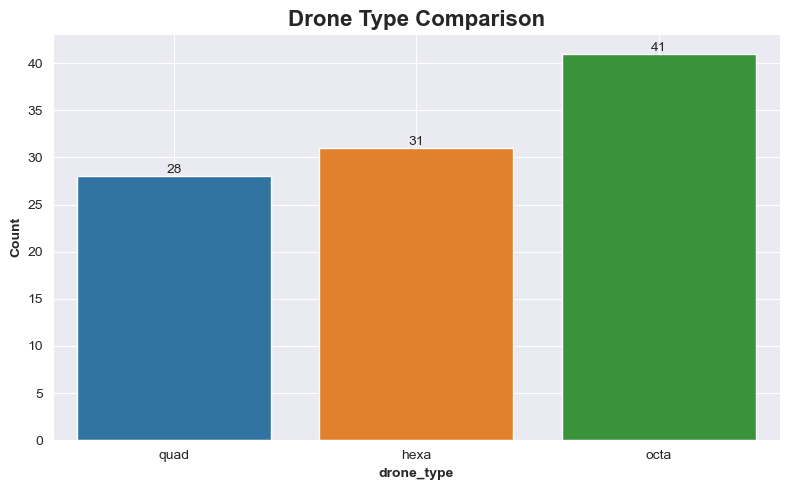

In [14]:
plot_bar(df_clean,x='drone_type',title='Drone Type Comparison')

The dataset contains more octa (41) drones compared to heax (31) and quad drones (28) . This suggests that octa drones are the most common drone type in the dataset.

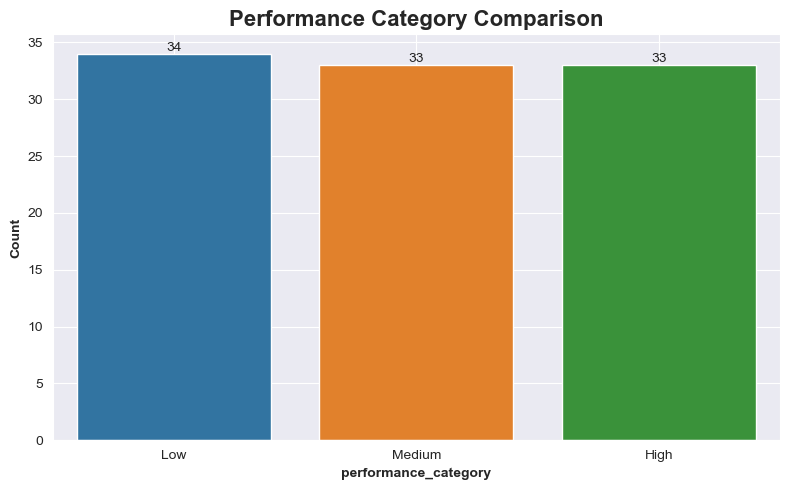

In [15]:
plot_bar(df_clean,x='performance_category',title='Performance Category Comparison')

The distribution of drones across performance categories is relatively balanced, with 34 low-perfomance drones and 33 drones each in the medium and high categories.

# Distribution Analysis

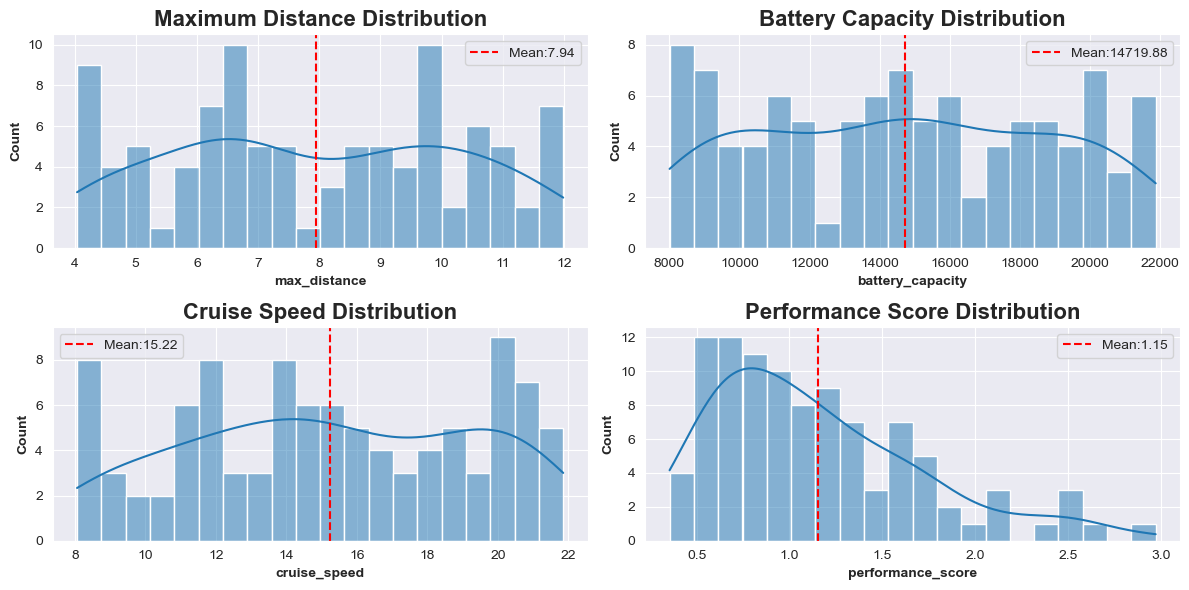

In [16]:
fig, axes = plt.subplots(2,2,figsize=(12,6))
plot_hist(df_clean,column='max_distance',title='Maximum Distance Distribution',ax=axes[0,0])
plot_hist(df_clean,column='battery_capacity',title="Battery Capacity Distribution",ax=axes[0,1])
plot_hist(df_clean,column='cruise_speed',title="Cruise Speed Distribution",ax=axes[1,0])
plot_hist(df_clean,column='performance_score',title='Performance Score Distribution',ax=axes[1,1])
plt.tight_layout()
plt.savefig(f"Picture/Dashboard.jpg",dpi=300)

plt.show()

The histograms illustrate the distribution of key drone specifications such as battery capacity, weight and cruise speed are concentrated within moderate ranges.This indicates that the dataset mainly represent mid-range drone models rather than extreme high or low specifications.

# Drone Type Performance Comparison

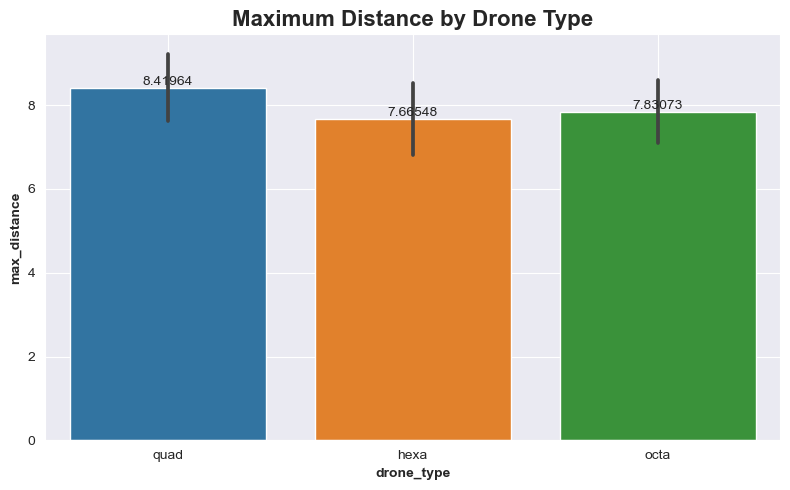

In [17]:
plot_bar(df_clean,x='drone_type',y='max_distance',title='Maximum Distance by Drone Type')

Quad drones have the highest average maximum flight distance followed by octa and hexa drones, indicating that quad drones tend to travel slightly farther.

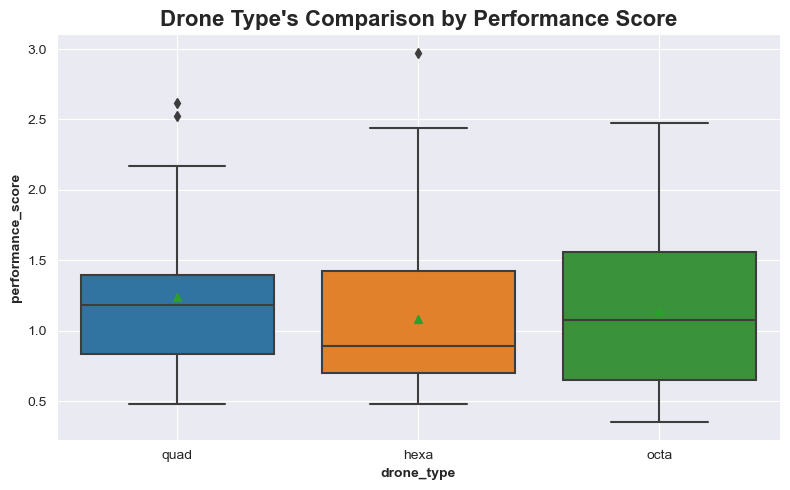

In [18]:
plot_box(df_clean,x='drone_type',y='performance_score',title='Drone Type\'s Comparison by Performance Score')

Quad drones show a slightly higher median performance score, while hexa and octa drones have similar distributions. The overlapping ranges suggest that performance difference between drone types are relatively small.

# Performance Category Comparison


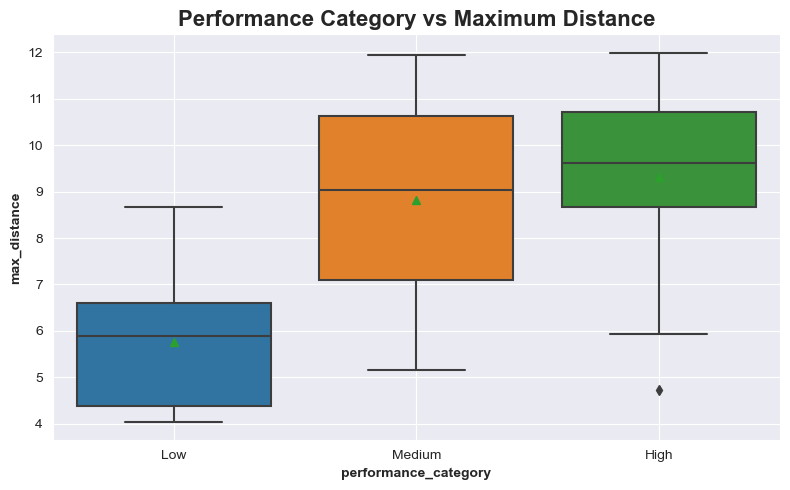

In [19]:
plot_box(df_clean,x='performance_category',y='max_distance',title='Performance Category vs Maximum Distance')

The box plot illustrates that drones with higher performance categories tend to achieve greater maximum flight distances. The median distance increases from the low to high category, indicating a positive relationship between performance score and flight distance.

# Relationship Analysis

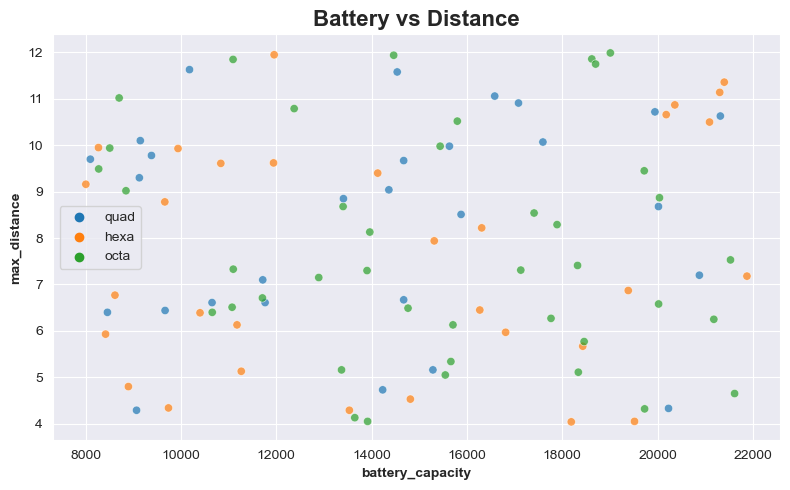

In [26]:
plot_scatter(df_clean,x='battery_capacity',y='max_distance',hue='drone_type',title='Battery vs Distance')


Battery Capacity shows a slight positive relationship with maximum flight distance.Drones with higher battery capacities tend to achieve longer flight distance.
However, drones with similar battery capacities sometimes reach different distances,suggesting that other factors such as power efficiency or wieght may also affect flight performance.

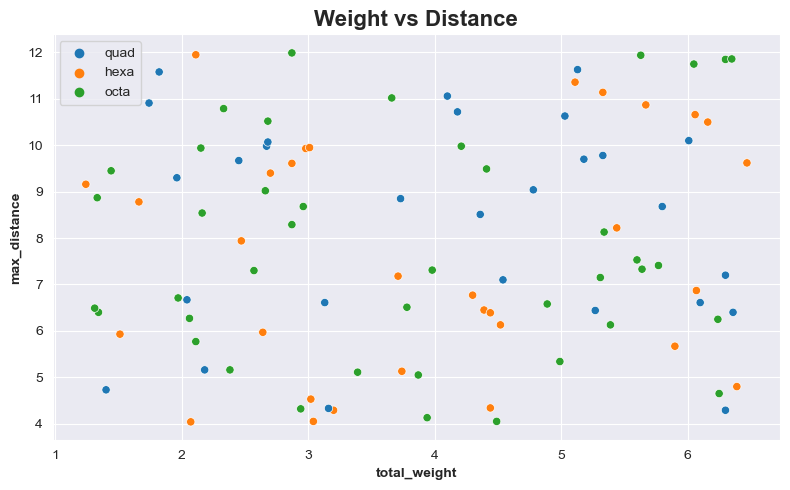

In [21]:
plot_scatter(df_clean,x='total_weight',y='max_distance',hue='drone_type',title='Weight vs Distance')

The scatter plot shows no clear relationship between drone weight and maximum flight distance. Drones with different weights achieve similar flight distances, suggesting that weight alone does not strongly influence flight range.

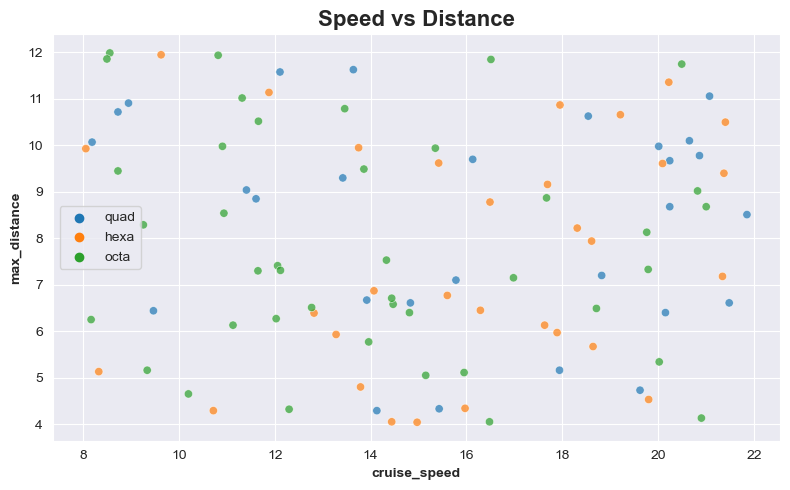

In [27]:
plot_scatter(df_clean,x='cruise_speed',y='max_distance',hue='drone_type',title='Speed vs Distance')


The scatter plot shows a weak relationship between cruise speed and maximum flight distance. Drones with differnt speeds achieve similar flight distances, indicating that speed alone does not strongly affect flight range.

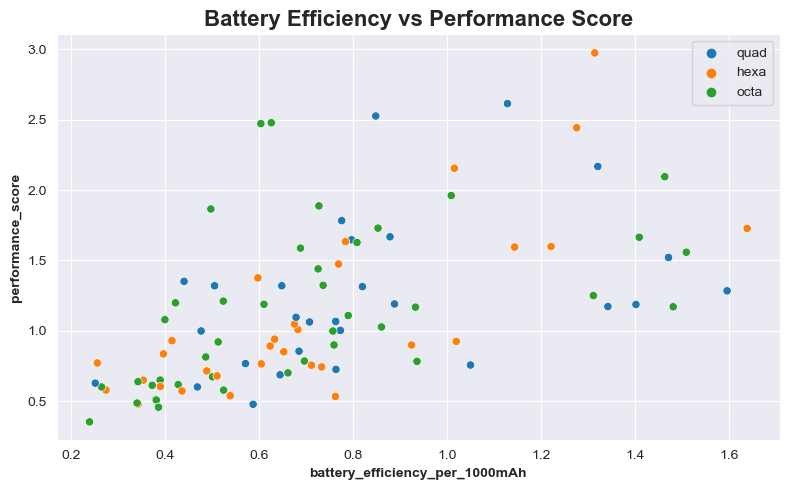

In [23]:
plot_scatter(df_clean,x='battery_efficiency_per_1000mAh',y='performance_score',hue='drone_type',title='Battery Efficiency vs Performance Score')

The scatter shows a positive relationship between battery efficiency and performance score. Drones with higher battery efficiency tend to achieve better overall performance.

# Correlation Analysis

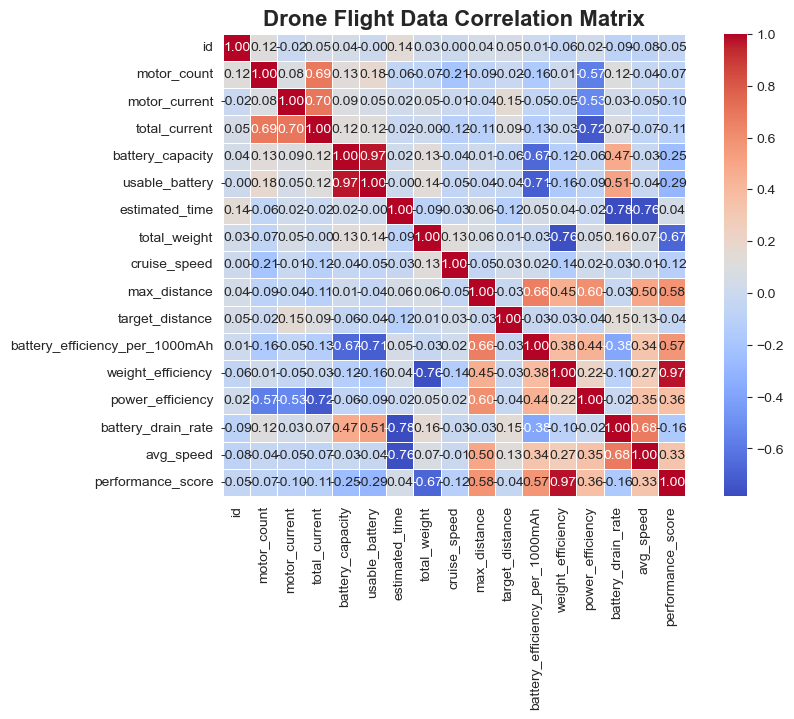

In [24]:
plt.figure(figsize=(10,6))
corr = df_clean.corr()
sns.heatmap(corr,
           annot = True,
           cmap = "coolwarm",
           square= True,
           linewidths= 0.5, 
           fmt = '.2f')
plt.title('Drone Flight Data Correlation Matrix',weight='bold',size='16')
plt.savefig(f"Picture/correlation_analysis.jpg",dpi=300)
plt.show()

The heatmap shows that battery capacity strongly correlates with usable battery, while maximum flight distance is moderately related to battery efficiency and power efficiency. This suggests that energy efficiency is an important factor affecting dron flight range.

 ## ##Final Insights

- Battery capacity has a strong relationship with usable battery power.
- Energy efficiency metrics such as battery efficiency and power efficiency contribute to longer flight distances.
- Drone types show only small differences in maximum flight distance.
- Higher performance category drones generally achieve longer flight ranges.
- Most other variables show weak correlations with flight distance.
- Quad drones show slightly better distance performance compared to other types.

##  ##Recommendations

- Improving battery efficiency could significantly increase drone flight distances.
- Optimizing energy consumption may enhance overall drone performance.
- Manufacturers could focus on battery technology to enhance long distance drone capability.

## Final Conclusion 

The analysis explored the relationship between drone characteristics such as speed, weight, battery efficiency and performance.
The results show that cruise speed and drone weight have weak relationships with flight distance. In contrast, battery efficiency demonstrates a positive relationship with performance score, indicating that efficient energy usage plays an important role in overall drone performance.
These findings suggest that improving battery efficiency can significantly enhance drone performance compared to focusing only on speed or weight.